# Обнаружение мошенничества в банковских транзакциях

Модель классификации для выявления мошеннических транзакций с использованием CatBoost.
Данные агрегированы на уровне клиентов для надежного предсказания мошенничества.
**Версия Pro: Подбор гиперпараметров с Optuna (100 итераций, оптимизация на F0.5)**

## Часть 1: Настройка окружения

Инициализация зависимостей, логирования и параметров визуализации.

In [1]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    average_precision_score
)
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Setup
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
logger.info("Environment initialized successfully")

/Users/berdov/project3/fraud_detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-08 13:45:01,586 - INFO - Environment initialized successfully


## Часть 2: Загрузка и исследование данных

Загрузка тренировочного и тестового наборов, анализ структуры и распределения мошенничества.

In [2]:
df_train = pd.read_csv("train.csv", index_col=False)
df_test = pd.read_csv("test.csv", index_col=False)
df_val = pd.read_csv("val.csv", index_col=False)

logger.info(f"Training set: {df_train.shape[0]:,} rows x {df_train.shape[1]} columns")
logger.info(f"Validation set: {df_val.shape[0]:,} rows x {df_val.shape[1]} columns")
logger.info(f"Test set: {df_test.shape[0]:,} rows x {df_test.shape[1]} columns")
logger.info(f"Fraud rate (train): {df_train['FraudResult'].mean():.2%}")
logger.info(f"Fraud rate (val): {df_val['FraudResult'].mean():.2%}")
logger.info(f"Fraud rate (test): {df_test['FraudResult'].mean():.2%}")

print("\nData Summary:")
print(f"  Training samples: {df_train.shape[0]:>8,}")
print(f"  Validation samples: {df_val.shape[0]:>8,}")
print(f"  Test samples:     {df_test.shape[0]:>8,}")
print(f"  Features:         {df_train.shape[1]:>8}")

2026-04-08 13:45:01,678 - INFO - Training set: 54,459 rows x 10 columns
2026-04-08 13:45:01,678 - INFO - Validation set: 21,537 rows x 10 columns
2026-04-08 13:45:01,679 - INFO - Test set: 19,666 rows x 10 columns
2026-04-08 13:45:01,679 - INFO - Fraud rate (train): 0.17%
2026-04-08 13:45:01,679 - INFO - Fraud rate (val): 0.21%
2026-04-08 13:45:01,680 - INFO - Fraud rate (test): 0.29%



Data Summary:
  Training samples:   54,459
  Validation samples:   21,537
  Test samples:       19,666
  Features:               10


### Анализ распределения энтитетов

In [3]:
# Data already split in CSV files (train.csv vs val.csv vs test.csv)
logger.info("Data split: using pre-split train.csv, val.csv, and test.csv")

2026-04-08 13:45:01,683 - INFO - Data split: using pre-split train.csv, val.csv, and test.csv


## Часть 3: Обработка признаков

Острание числовых идентификаторов, Офрормление временных признаков и кодирование категориальных полей.

In [4]:
id_analysis = {
    'Total rows': df_train.shape[0],
    'Unique CustomerId': df_train['CustomerId'].nunique(),
}

print("\nEntity Cardinality in Training Set:")
print("-" * 40)
for key, val in id_analysis.items():
    print(f"  {key:<25} {val:>10,}")


Entity Cardinality in Training Set:
----------------------------------------
  Total rows                    54,459
  Unique CustomerId              2,245


### Функция обработки данных

In [5]:
def prepare_fraud_data(df):
    """
    Feature engineering and data preparation pipeline.
    
    Processing steps:
    1. Extract numeric IDs from string identifiers
    2. Convert datetime to temporal features
    3. Encode categorical variables
    4. Drop uninformative columns
    
    Args:
        df: Input dataframe
        
    Returns:
        Preprocessed dataframe ready for modeling
    """
    df = df.copy()
    
    # Extract numeric IDs (excludes deleted columns: BatchId, AccountId, SubscriptionId)
    id_columns = [
        "TransactionId", "ProviderId", "ProductId", "ChannelId"
    ]
    
    for col in id_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.extract(r"(\d+)$", expand=False).astype("Int64")
    
    # Temporal features
    if "TransactionStartTime" in df.columns:
        df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"], utc=True)
        df["tx_year"] = df["TransactionStartTime"].dt.year
        df["tx_month"] = df["TransactionStartTime"].dt.month
        df["tx_day"] = df["TransactionStartTime"].dt.day
        df["tx_hour"] = df["TransactionStartTime"].dt.hour
        df["tx_minute"] = df["TransactionStartTime"].dt.minute
        df["tx_dayofweek"] = df["TransactionStartTime"].dt.dayofweek
        df["tx_is_weekend"] = (df["TransactionStartTime"].dt.dayofweek >= 5).astype(int)
        df = df.drop(columns=["TransactionStartTime"])
    return df.reset_index(drop=True)

### Apply Preprocessing Pipeline

In [6]:
logger.info("Starting data preprocessing...")
train_prep = prepare_fraud_data(df_train)
val_prep = prepare_fraud_data(df_val)
test_prep = prepare_fraud_data(df_test)

logger.info(f"Preprocessed training: {train_prep.shape}")
logger.info(f"Preprocessed validation: {val_prep.shape}")
logger.info(f"Preprocessed test: {test_prep.shape}")
logger.info(f"Features after preprocessing: {train_prep.shape[1]}")

2026-04-08 13:45:01,697 - INFO - Starting data preprocessing...
2026-04-08 13:45:01,879 - INFO - Preprocessed training: (54459, 16)
2026-04-08 13:45:01,879 - INFO - Preprocessed validation: (21537, 16)
2026-04-08 13:45:01,879 - INFO - Preprocessed test: (19666, 16)
2026-04-08 13:45:01,879 - INFO - Features after preprocessing: 16


### Feature Selection

In [7]:
TARGET_COL = "FraudResult"
CLIENT_ID_COL = "CustomerId"

# Columns to exclude from model features (deleted columns removed)
EXCLUDE_COLS = {
    TARGET_COL,           # target variable
    "TransactionId",      # transaction identifier
    "CustomerId",         # customer identifier (for aggregation only)
}

feature_cols = [col for col in train_prep.columns if col not in EXCLUDE_COLS]
cat_features = [col for col in ["ProductCategory"] if col in feature_cols]
logger.info(f"Selected {len(feature_cols)} features for modeling")
print(f"\nFeatures: {', '.join(sorted(feature_cols))}")

2026-04-08 13:45:01,883 - INFO - Selected 13 features for modeling



Features: Amount, ChannelId, PricingStrategy, ProductCategory, ProductId, ProviderId, tx_day, tx_dayofweek, tx_hour, tx_is_weekend, tx_minute, tx_month, tx_year


### Подготовка матриц обучения

In [8]:
X_train = train_prep[feature_cols].copy()
y_train = train_prep[TARGET_COL].copy()

X_val = val_prep[feature_cols].copy()
y_val = val_prep[TARGET_COL].copy()

X_test = test_prep[feature_cols].copy()
y_test = test_prep[TARGET_COL].copy()

# Balance check
fraud_ratio_train = y_train.mean()
fraud_ratio_val = y_val.mean()
fraud_ratio_test = y_test.mean()

logger.info(f"Training set: {len(X_train):,} samples, {fraud_ratio_train:.2%} fraud")
logger.info(f"Validation set: {len(X_val):,} samples, {fraud_ratio_val:.2%} fraud")
logger.info(f"Test set: {len(X_test):,} samples, {fraud_ratio_test:.2%} fraud")

print(f"\nMatrix dimensions:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

2026-04-08 13:45:01,892 - INFO - Training set: 54,459 samples, 0.17% fraud
2026-04-08 13:45:01,893 - INFO - Validation set: 21,537 samples, 0.21% fraud
2026-04-08 13:45:01,893 - INFO - Test set: 19,666 samples, 0.29% fraud



Matrix dimensions:
  X_train: (54459, 13)
  y_train: (54459,)
  X_val: (21537, 13)
  y_val: (21537,)
  X_test: (19666, 13)
  y_test: (19666,)


## Часть 4: Подбор гиперпараметров с Optuna

Оптимизация 100 итераций на F0.5 с использованием Optuna и CatBoost.

[I 2026-04-08 13:45:01,902] A new study created in memory with name: no-name-71e64863-04d8-4319-bb16-733838ac6d83
2026-04-08 13:45:01,903 - INFO - Starting Optuna optimization: 100 trials...
Best trial: 0. Best value: 0.538462:   1%|          | 1/100 [00:01<02:35,  1.58s/it]

[I 2026-04-08 13:45:03,484] Trial 0 finished with value: 0.5384615384615384 and parameters: {'depth': 6, 'learning_rate': 0.22648248189516842, 'l2_leaf_reg': 29.10635913133069, 'subsample': 0.7993292420985183, 'iterations': 700, 'random_strength': 0.20511104188433976, 'border_count': 45, 'bagging_temperature': 8.661761457749352, 'leaf_estimation_iterations': 7}. Best is trial 0 with value: 0.5384615384615384.


Best trial: 1. Best value: 0.684932:   2%|▏         | 2/100 [00:02<01:48,  1.11s/it]

[I 2026-04-08 13:45:04,268] Trial 1 finished with value: 0.684931506849315 and parameters: {'depth': 8, 'learning_rate': 0.001124579825911934, 'l2_leaf_reg': 87.06020878304857, 'subsample': 0.9162213204002109, 'iterations': 800, 'random_strength': 0.23102018878452935, 'border_count': 73, 'bagging_temperature': 3.0424224295953772, 'leaf_estimation_iterations': 6}. Best is trial 1 with value: 0.684931506849315.


Best trial: 2. Best value: 0.943396:   3%|▎         | 3/100 [00:03<02:10,  1.35s/it]

...

[I 2026-04-08 13:47:13,210] Trial 97 finished with value: 0.9420289855072463 and parameters: {'depth': 7, 'learning_rate': 0.07085468429750881, 'l2_leaf_reg': 1.9112777118852868, 'subsample': 0.8205671547539543, 'iterations': 500, 'random_strength': 1.0449919363607052, 'border_count': 127, 'bagging_temperature': 2.9502272707327695, 'leaf_estimation_iterations': 8}. Best is trial 28 with value: 1.0.


Best trial: 28. Best value: 1:  99%|█████████▉| 99/100 [02:12<00:01,  1.11s/it]

[I 2026-04-08 13:47:14,129] Trial 98 finished with value: 0.9433962264150944 and parameters: {'depth': 6, 'learning_rate': 0.04675493135700068, 'l2_leaf_reg': 2.4038456542581907, 'subsample': 0.8924799146073974, 'iterations': 600, 'random_strength': 0.15137686391343275, 'border_count': 251, 'bagging_temperature': 5.530290268973267, 'leaf_estimation_iterations': 9}. Best is trial 28 with value: 1.0.


Best trial: 28. Best value: 1: 100%|██████████| 100/100 [02:14<00:00,  1.34s/it]
2026-04-08 13:47:16,268 - INFO - Best trial: F0.5 = 1.000000
2026-04-08 13:47:16,268 - INFO - Best hyperparameters:
2026-04-08 13:47:16,268 - INFO -   depth: 6
2026-04-08 13:47:16,268 - INFO -   learning_rate: 0.021708415498150092
2026-04-08 13:47:16,268 - INFO -   l2_leaf_reg: 2.0471105563346845
2026-04-08 13:47:16,269 - INFO -   subsample: 0.6802283535060114
2026-04-08 13:47:16,269 - INFO -   iterations: 1500
2026-04-08 13:47:16,269 - INFO -   random_strength: 0.3166705505716121
2026-04-08 13:47:16,270 - INFO -   border_count: 232
2026-04-08 13:47:16,270 - INFO -   bagging_temperature: 1.6680844520447655
2026-04-08 13:47:16,270 - INFO -   leaf_estimation_iterations: 9


[I 2026-04-08 13:47:16,265] Trial 99 finished with value: 1.0 and parameters: {'depth': 4, 'learning_rate': 0.0064916796358113205, 'l2_leaf_reg': 3.0201093703621176, 'subsample': 0.8421564741093464, 'iterations': 1100, 'random_strength': 0.36163427932414743, 'border_count': 244, 'bagging_temperature': 3.875648823684484, 'leaf_estimation_iterations': 10}. Best is trial 28 with value: 1.0.

                    OPTUNA OPTIMIZATION RESULTS (100 trials)                    

Best F0.5: 1.000000

Best Hyperparameters:
--------------------------------------------------------------------------------
  bagging_temperature                   1.668084
  border_count                               232
  depth                                        6
  iterations                                1500
  l2_leaf_reg                           2.047111
  leaf_estimation_iterations                   9
  learning_rate                         0.021708
  random_strength                       0.316671
  subsampl

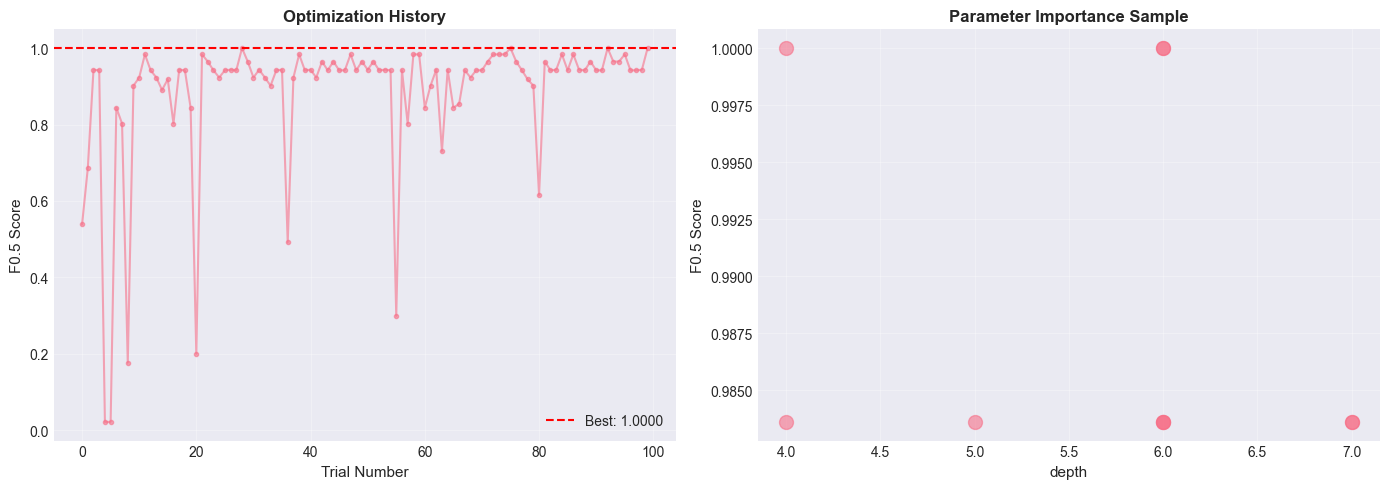


Optimization completed successfully


In [9]:
def objective(trial):
    """
    Optuna objective function for CatBoost hyperparameter tuning.
    Optimizes F0.5 on validation set.
    """

    depth = trial.suggest_int('depth', 4, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.3, log=True)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1, 100, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    iterations = trial.suggest_int('iterations', 500, 2000, step=100)
    random_strength = trial.suggest_float('random_strength', 0.1, 10.0, log=True)
    border_count = trial.suggest_int('border_count', 32, 255)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 10.0)
    leaf_estimation_iterations = trial.suggest_int('leaf_estimation_iterations', 1, 10)

    model = CatBoostClassifier(
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        subsample=subsample,
        iterations=iterations,
        random_strength=random_strength,
        border_count=border_count,
        bagging_temperature=bagging_temperature,
        leaf_estimation_iterations=leaf_estimation_iterations,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=50,
        eval_metric='PRAUC',
        use_best_model=True
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        cat_features=cat_features,
        plot=False
    )

    y_val_score = model.predict_proba(X_val)[:, 1]
    val_client_data = pd.DataFrame({
        CLIENT_ID_COL: val_prep[CLIENT_ID_COL].values,
        'y_true': y_val.values,
        'y_score': y_val_score
    })

    val_client_eval = val_client_data.groupby(CLIENT_ID_COL, as_index=False).agg({
        'y_true': 'max',
        'y_score': 'max'
    })

    y_val_client_true = val_client_eval['y_true'].values
    y_val_client_score = val_client_eval['y_score'].values

    thresholds = np.arange(0.0, 1.01, 0.01)
    f05_scores = []

    for thresh in thresholds:
        y_val_client_pred = (y_val_client_score >= thresh).astype(int)
        f05 = fbeta_score(y_val_client_true, y_val_client_pred, beta=0.5, zero_division=0)
        f05_scores.append(f05)

    best_f05 = max(f05_scores)
    trial.report(best_f05, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return best_f05


# Create study
sampler = TPESampler(seed=42, n_startup_trials=5)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner
)

# Optimize for 100 trials
logger.info("Starting Optuna optimization: 100 trials...")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Get best trial
best_trial = study.best_trial
logger.info(f"Best trial: F0.5 = {best_trial.value:.6f}")
logger.info(f"Best hyperparameters:")
for key, value in best_trial.params.items():
    logger.info(f"  {key}: {value}")

print("\n" + "="*80)
print(f"OPTUNA OPTIMIZATION RESULTS (100 trials)".center(80))
print("="*80)
print(f"\nBest F0.5: {best_trial.value:.6f}")
print(f"\nBest Hyperparameters:")
print("-"*80)
for key, value in sorted(best_trial.params.items()):
    if isinstance(value, float):
        print(f"  {key:<30} {value:>15.6f}")
    else:
        print(f"  {key:<30} {value:>15}")

# Visualization of optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial values over iterations
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, marker='o', markersize=3, alpha=0.6)
axes[0].axhline(best_trial.value, color='red', linestyle='--', label=f'Best: {best_trial.value:.4f}')
axes[0].set_xlabel('Trial Number', fontsize=11)
axes[0].set_ylabel('F0.5 Score', fontsize=11)
axes[0].set_title('Optimization History', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Slice plot for top 10 parameters
top_params = sorted(study.trials[-50:], key=lambda t: t.value if t.value else 0, reverse=True)[:10]
param_names = list(best_trial.params.keys())
param_values = {name: [] for name in param_names}
scores = []

for trial in top_params:
    if trial.value:
        for name in param_names:
            param_values[name].append(trial.params.get(name))
        scores.append(trial.value)

# Plot variation of top parameter
if param_values[param_names[0]]:
    axes[1].scatter(param_values[param_names[0]], scores, s=100, alpha=0.6)
    axes[1].set_xlabel(param_names[0], fontsize=11)
    axes[1].set_ylabel('F0.5 Score', fontsize=11)
    axes[1].set_title(f'Parameter Importance Sample', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nOptimization completed successfully")

## Часть 5: Обучение финальной модели

Обучение модели с лучшими найденными гиперпараметрами на train.

In [10]:
logger.info(f"Training final model on train data: {X_train.shape}")

final_model = CatBoostClassifier(
    depth=int(best_trial.params['depth']),
    learning_rate=best_trial.params['learning_rate'],
    l2_leaf_reg=best_trial.params['l2_leaf_reg'],
    subsample=best_trial.params['subsample'],
    iterations=int(best_trial.params['iterations']),
    random_strength=best_trial.params['random_strength'],
    border_count=int(best_trial.params['border_count']),
    bagging_temperature=best_trial.params['bagging_temperature'],
    leaf_estimation_iterations=int(best_trial.params['leaf_estimation_iterations']),
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    eval_metric='PRAUC',
    use_best_model=True
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    cat_features=cat_features,
    plot=False
)

logger.info("Final model training completed")

2026-04-08 13:47:16,427 - INFO - Training final model on train data: (54459, 13)


0:	learn: 0.1020176	test: 0.0233422	best: 0.0233422 (0)	total: 16.7ms	remaining: 25.1s


2026-04-08 13:47:17,406 - INFO - Final model training completed


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8352866787
bestIteration = 20

Shrink model to first 21 iterations.


## Часть 6: Инференс модели

Генерация предсказаний для тестового набора на уровне транзакций и клиентов.

In [11]:
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Diagnostic info
logger.info(f"Predictions generated for {len(y_pred_proba):,} test samples")
logger.info(f"Score statistics - Min: {y_pred_proba.min():.6f}, Max: {y_pred_proba.max():.6f}, Mean: {y_pred_proba.mean():.6f}")
logger.info(f"Scores >= 0.5: {(y_pred_proba >= 0.5).sum()}")

y_pred = (y_pred_proba >= 0.5).astype(int)

2026-04-08 13:47:17,414 - INFO - Predictions generated for 19,666 test samples
2026-04-08 13:47:17,414 - INFO - Score statistics - Min: 0.029147, Max: 0.633597, Mean: 0.044479
2026-04-08 13:47:17,414 - INFO - Scores >= 0.5: 54


### Агрегация на уровень клиентов

In [12]:
# Aggregate transaction-level predictions to client level
client_data = pd.DataFrame({
    CLIENT_ID_COL: test_prep[CLIENT_ID_COL].values,
    'y_true': y_test.values,
    'y_score': y_pred_proba
})

# Group by client, taking maximum score and fraud label
client_eval = client_data.groupby(CLIENT_ID_COL, as_index=False).agg({
    'y_true': 'max',
    'y_score': 'max'
})

client_eval.columns = [CLIENT_ID_COL, 'y_true_client', 'y_score_client']
client_eval['y_pred_client'] = (client_eval['y_score_client'] >= 0.5).astype(int)

logger.info(f"Aggregated to {len(client_eval):,} unique clients")
logger.info(f"Fraud cases (true): {(client_eval['y_true_client'] == 1).sum()}")
logger.info(f"Predicted fraud: {(client_eval['y_pred_client'] == 1).sum()}")
logger.info(f"Client-level score stats - Min: {client_eval['y_score_client'].min():.6f}, Max: {client_eval['y_score_client'].max():.6f}, Mean: {client_eval['y_score_client'].mean():.6f}")

2026-04-08 13:47:17,424 - INFO - Aggregated to 749 unique clients
2026-04-08 13:47:17,424 - INFO - Fraud cases (true): 9
2026-04-08 13:47:17,425 - INFO - Predicted fraud: 5
2026-04-08 13:47:17,425 - INFO - Client-level score stats - Min: 0.029861, Max: 0.633597, Mean: 0.071071


## Часть 7: Оценка модели

Расчет комплексных метрик, визуализация производительности, анализ по бакетам скора.

2026-04-08 13:47:17,492 - INFO - Оптимальный порог по validation: 0.52 (макс F0.5: 1.0000)



ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ CATBOOST PRO (OPTUNA + F0.5, КЛИЕНТСКИЙ УРОВЕНЬ)

СТАТИСТИКА НАБОРА ДАННЫХ:
--------------------------------------------------------------------------------
  Всего клиентов:                       749    (100.0%)
  Мошенники:                              9    (  1.2%)
  Честные:                              740    ( 98.8%)

РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:
--------------------------------------------------------------------------------
  Предсказано как мошенник:              5    (  0.7%)
  Предсказано как честный:             744    ( 99.3%)
  Оптимальный порог:                 0.5200

МАТРИЦА ОШИБОК:
--------------------------------------------------------------------------------
  Истинные негативы (TN):               740
  Ложные позитивы (FP):                   0
  Ложные негативы (FN):                   4
  Истинные позитивы (TP):                 5

МЕТРИКИ КАЧЕСТВА:
--------------------------------------------------------------------------------
  Accuracy   

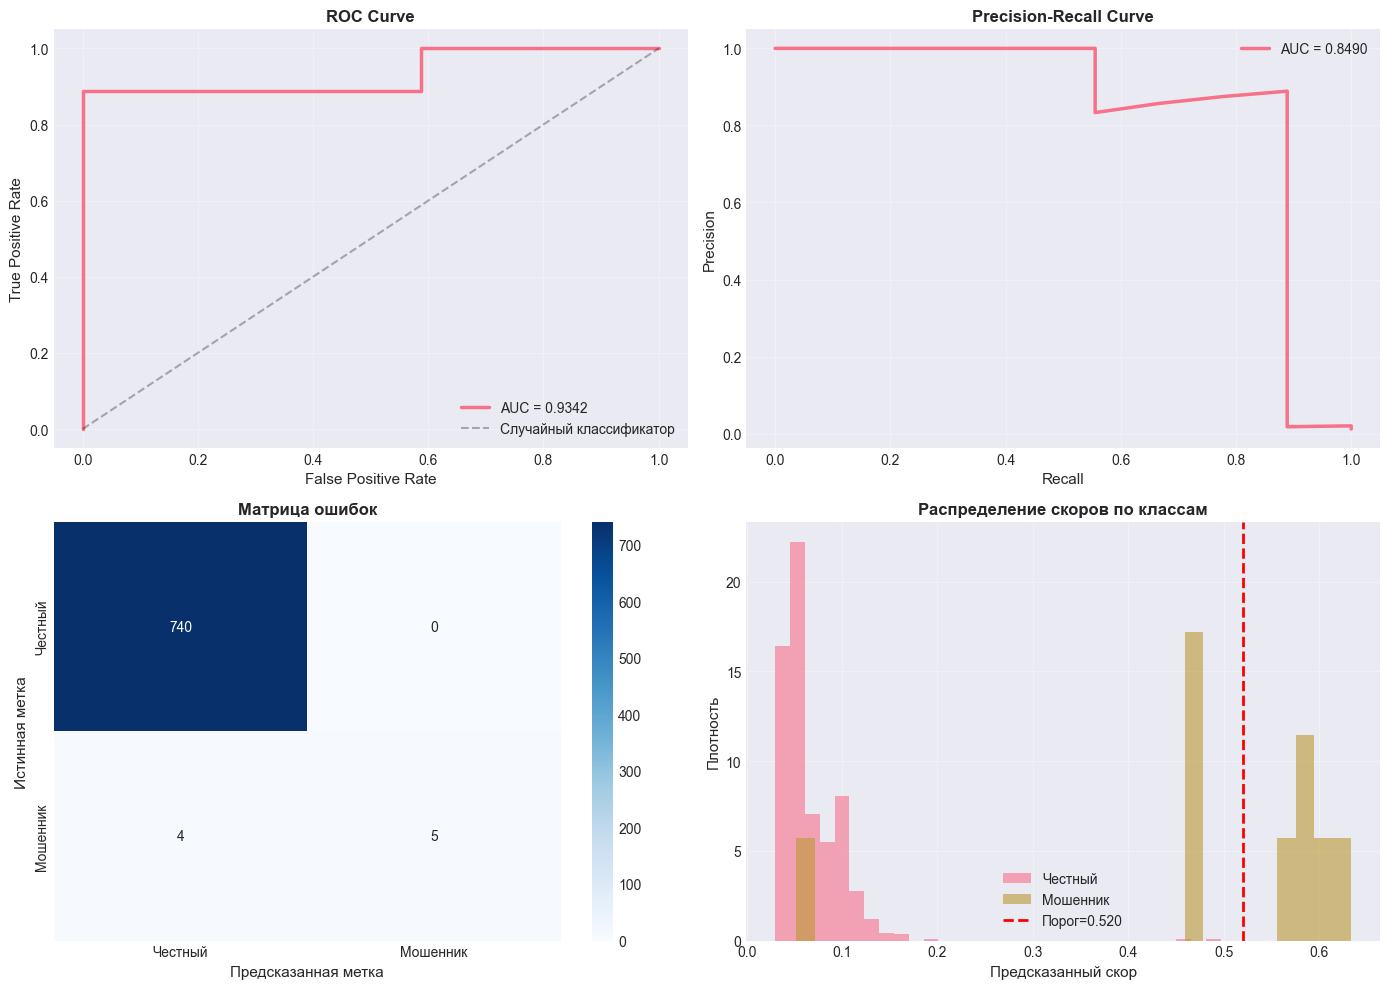

2026-04-08 13:47:17,708 - INFO - Оценка модели завершена успешно


In [13]:
y_true = client_eval['y_true_client'].values
y_score = client_eval['y_score_client'].values

# ===== Threshold selection on validation =====
val_pred_proba = final_model.predict_proba(X_val)[:, 1]

val_client_data = pd.DataFrame({
    CLIENT_ID_COL: val_prep[CLIENT_ID_COL].values,
    'y_true': y_val.values,
    'y_score': val_pred_proba
})

val_client_eval = val_client_data.groupby(CLIENT_ID_COL, as_index=False).agg({
    'y_true': 'max',
    'y_score': 'max'
})

val_client_eval.columns = [CLIENT_ID_COL, 'y_true_client', 'y_score_client']

y_val_client_true = val_client_eval['y_true_client'].values
y_val_client_score = val_client_eval['y_score_client'].values

thresholds = np.arange(0.0, 1.01, 0.01)
f05_scores = []

for thresh in thresholds:
    y_val_client_pred = (y_val_client_score >= thresh).astype(int)
    f05 = fbeta_score(y_val_client_true, y_val_client_pred, beta=0.5, zero_division=0)
    f05_scores.append(f05)

optimal_thresh = thresholds[np.argmax(f05_scores)]

logger.info(f"Оптимальный порог по validation: {optimal_thresh:.2f} (макс F0.5: {max(f05_scores):.4f})")

y_true = client_eval['y_true_client'].values
y_score = client_eval['y_score_client'].values
y_pred = (y_score >= optimal_thresh).astype(int)

# Calculate metrics
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics = {
    'ROC-AUC': roc_auc_score(y_true, y_score),
    'PR-AUC': average_precision_score(y_true, y_score),
    'Accuracy': accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred, zero_division=0),
    'Recall': recall_score(y_true, y_pred, zero_division=0),
    'F1': f1_score(y_true, y_pred, zero_division=0),
    'F0.5': fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
    'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
}

# Print formatted report
print("\n" + "="*80)
print("ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ CATBOOST PRO (OPTUNA + F0.5, КЛИЕНТСКИЙ УРОВЕНЬ)")
print("="*80)

print("\nСТАТИСТИКА НАБОРА ДАННЫХ:")
print("-"*80)
n_total = len(client_eval)
n_fraud = (y_true == 1).sum()
n_nonfraud = (y_true == 0).sum()
print(f"  Всего клиентов:                {n_total:>10,}    ({100.0:>5.1f}%)")
print(f"  Мошенники:                     {n_fraud:>10,}    ({100*n_fraud/n_total:>5.1f}%)")
print(f"  Честные:                       {n_nonfraud:>10,}    ({100*n_nonfraud/n_total:>5.1f}%)")

print("\nРАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:")
print("-"*80)
n_pred_fraud = (y_pred == 1).sum()
n_pred_legit = (y_pred == 0).sum()
print(f"  Предсказано как мошенник:     {n_pred_fraud:>10,}    ({100*n_pred_fraud/n_total:>5.1f}%)")
print(f"  Предсказано как честный:      {n_pred_legit:>10,}    ({100*n_pred_legit/n_total:>5.1f}%)")
print(f"  Оптимальный порог:             {optimal_thresh:>10.4f}")

print("\nМАТРИЦА ОШИБОК:")
print("-"*80)
print(f"  Истинные негативы (TN):        {tn:>10,}")
print(f"  Ложные позитивы (FP):          {fp:>10,}")
print(f"  Ложные негативы (FN):          {fn:>10,}")
print(f"  Истинные позитивы (TP):        {tp:>10,}")

print("\nМЕТРИКИ КАЧЕСТВА:")
print("-"*80)
for metric_name, metric_value in sorted(metrics.items()):
    print(f"  {metric_name:<25} {metric_value:>10.4f}")

print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ:")
print("-"*80)
print(classification_report(y_true, y_pred, target_names=['Честный', 'Мошенник'], 
                          digits=4, zero_division=0))

# Parity by scoring buckets
print("ПАРИТЕТ ПО БАКЕТАМ СКОРА (интервалы 0.1):")
print("-"*80)
buckets = pd.cut(y_score, bins=10, labels=[f"{i*0.1:.1f}-{(i+1)*0.1:.1f}" for i in range(10)])
parity_df = pd.DataFrame({
    'bucket': buckets,
    'y_true': y_true,
    'y_score': y_score
})

parity_stats = parity_df.groupby('bucket', observed=True).agg({
    'y_true': ['count', 'sum', 'mean'],
    'y_score': ['min', 'max', 'mean']
}).round(4)

parity_stats.columns = ['count', 'fraud_count', 'fraud_rate', 'score_min', 'score_max', 'score_mean']
print(parity_stats.to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
axes[0, 0].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {metrics["ROC-AUC"]:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Случайный классификатор')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# PR Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
axes[0, 1].plot(recall_vals, precision_vals, linewidth=2.5, label=f'AUC = {metrics["PR-AUC"]:.4f}')
axes[0, 1].set_xlabel('Recall', fontsize=11)
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
           xticklabels=['Честный', 'Мошенник'],
           yticklabels=['Честный', 'Мошенник'])
axes[1, 0].set_ylabel('Истинная метка', fontsize=11)
axes[1, 0].set_xlabel('Предсказанная метка', fontsize=11)
axes[1, 0].set_title('Матрица ошибок', fontsize=12, fontweight='bold')

# Score Distribution
axes[1, 1].hist(y_score[y_true == 0], bins=30, alpha=0.6, label='Честный', density=True)
axes[1, 1].hist(y_score[y_true == 1], bins=30, alpha=0.6, label='Мошенник', density=True)
axes[1, 1].axvline(optimal_thresh, color='red', linestyle='--', linewidth=2, label=f'Порог={optimal_thresh:.3f}')
axes[1, 1].set_xlabel('Предсказанный скор', fontsize=11)
axes[1, 1].set_ylabel('Плотность', fontsize=11)
axes[1, 1].set_title('Распределение скоров по классам', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("="*80)
logger.info("Оценка модели завершена успешно")